# Phase 2: Federated Agent Partitioning & Isolation Analysis
**Author**: MSc Project Student  
**Context**: This notebook demonstrates the Phase 2 isolated simulation. Here, the global SCM dataset is sliced, and two independent RL agents (Agent 1 and Agent 2) attempt to discover their local causal graphs. We also demonstrate a light hyperparameter sweep to tune learning rates and batch sizes before fully visualizing the convergence and overlap errors.


In [1]:
import sys
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Ensure src modules can be imported
module_path = os.path.abspath(os.path.join('.'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.scm.generator import LinearGaussianSCM
from src.scm.partition import partition_data
from src.rl.env import CausalDiscoveryEnv
from src.rl.agent import DDQNAgent
from src.rl.metrics import compute_shd, compute_overlap_metrics

# Reproducibility
np.random.seed(42)


## Slicing the Global Dataset
We extract the $6 	imes 6$ subgraphs for Agent 1 ($V_1 \dots V_6$) and Agent 2 ($V_5 \dots V_{10}$) from the global $10 	imes 10$ DAG.


In [2]:
# Initialize SCM and generate dataset
scm = LinearGaussianSCM(num_vars=10, random_seed=42)
data = scm.generate_data(num_samples=2000)

centralized, agent1_data, agent2_data = partition_data(data)
true_dag = scm.adjacency_matrix

agent1_true_dag = true_dag[0:6, 0:6]
agent2_true_dag = true_dag[4:10, 4:10]

print(f"Agent 1 Data Shape: {agent1_data.shape}")
print(f"Agent 2 Data Shape: {agent2_data.shape}")


Agent 1 Data Shape: (2000, 6)
Agent 2 Data Shape: (2000, 6)


In [3]:
def train_agent_loop(data, true_subgraph, overlap_indices, lr=1e-3, batch_size=32, episodes=30):
    env = CausalDiscoveryEnv(data, max_steps=40, step_cost=0.01)
    agent = DDQNAgent(obs_size=36, action_size=env.action_space.n, lr=lr)
    
    epsilon, epsilon_end, epsilon_decay = 1.0, 0.05, 0.95
    best_bic = float('inf')
    champion_dag = None
    
    metrics = {'shd': [], 'reward': [], 'tpr': [], 'fdr': []}
    v5_idx, v6_idx = overlap_indices
    
    for episode in range(episodes):
        obs, info = env.reset()
        mask = info['action_mask']
        done = False
        ep_reward = 0.0
        
        while not done:
            action = agent.select_action(obs, mask, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_mask = info['action_mask']
            done = terminated or truncated
            
            agent.replay_buffer.push(obs, action, reward, next_obs, next_mask, done)
            agent.update(batch_size=batch_size)
            
            ep_reward += reward
            obs, mask = next_obs, next_mask
            
            if info['bic'] < best_bic:
                best_bic = info['bic']
                champion_dag = env.adjacency_matrix.copy()
                
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        if (episode + 1) % 5 == 0:
            agent.update_target_network()
            
        current_shd = compute_shd(champion_dag, true_subgraph) if champion_dag is not None else 15
        tpr, fdr = compute_overlap_metrics(champion_dag, true_subgraph, v5_idx, v6_idx) if champion_dag is not None else (0,0)
        
        metrics['shd'].append(current_shd)
        metrics['reward'].append(ep_reward)
        metrics['tpr'].append(tpr)
        metrics['fdr'].append(fdr)
        
    return champion_dag, metrics, best_bic


## Light Hyperparameter Tuning
We run a short grid search over learning rates and batch sizes on Agent 1 to determine a good configuration before executing the final simulated run.


In [4]:
learning_rates = [1e-3, 5e-4]
batch_sizes = [16, 32]
best_config = None
lowest_shd = float('inf')

print("Starting Hyperparameter Sweep for Agent 1...")
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Testing LR: {lr}, Batch Size: {bs} ...")
        # Run a short 20-episode test
        _, metrics, _ = train_agent_loop(agent1_data, agent1_true_dag, (4,5), lr=lr, batch_size=bs, episodes=20)
        final_shd = metrics['shd'][-1]
        
        if final_shd < lowest_shd:
            lowest_shd = final_shd
            best_config = {'lr': lr, 'batch_size': bs}

print(f"\nBest Config Found: {best_config} with SHD={lowest_shd}")


Starting Hyperparameter Sweep for Agent 1...
Testing LR: 0.001, Batch Size: 16 ...
Testing LR: 0.001, Batch Size: 32 ...
Testing LR: 0.0005, Batch Size: 16 ...
Testing LR: 0.0005, Batch Size: 32 ...

Best Config Found: {'lr': 0.001, 'batch_size': 32} with SHD=1


## Independent Agent Training
Using the optimal parameters, we now run isolated trainings for both Agent 1 and Agent 2. We track their metrics independently.


In [5]:
opt_lr = best_config['lr']
opt_bs = best_config['batch_size']

print("Training Agent 1 (Observed V1-V6)...")
a1_dag, a1_metrics, a1_bic = train_agent_loop(agent1_data, agent1_true_dag, (4,5), lr=opt_lr, batch_size=opt_bs, episodes=40)

print("Training Agent 2 (Observed V5-V10)...")
a2_dag, a2_metrics, a2_bic = train_agent_loop(agent2_data, agent2_true_dag, (0,1), lr=opt_lr, batch_size=opt_bs, episodes=40)

print("Training Complete!")


Training Agent 1 (Observed V1-V6)...
Training Agent 2 (Observed V5-V10)...
Training Complete!


## Convergence and Error Visualization
We observe the SHD and Rewards. Critically, we look at the FDR for Agent 2 on the $V_5 \leftrightarrow V_6$ edge to spot relative latent confounding.


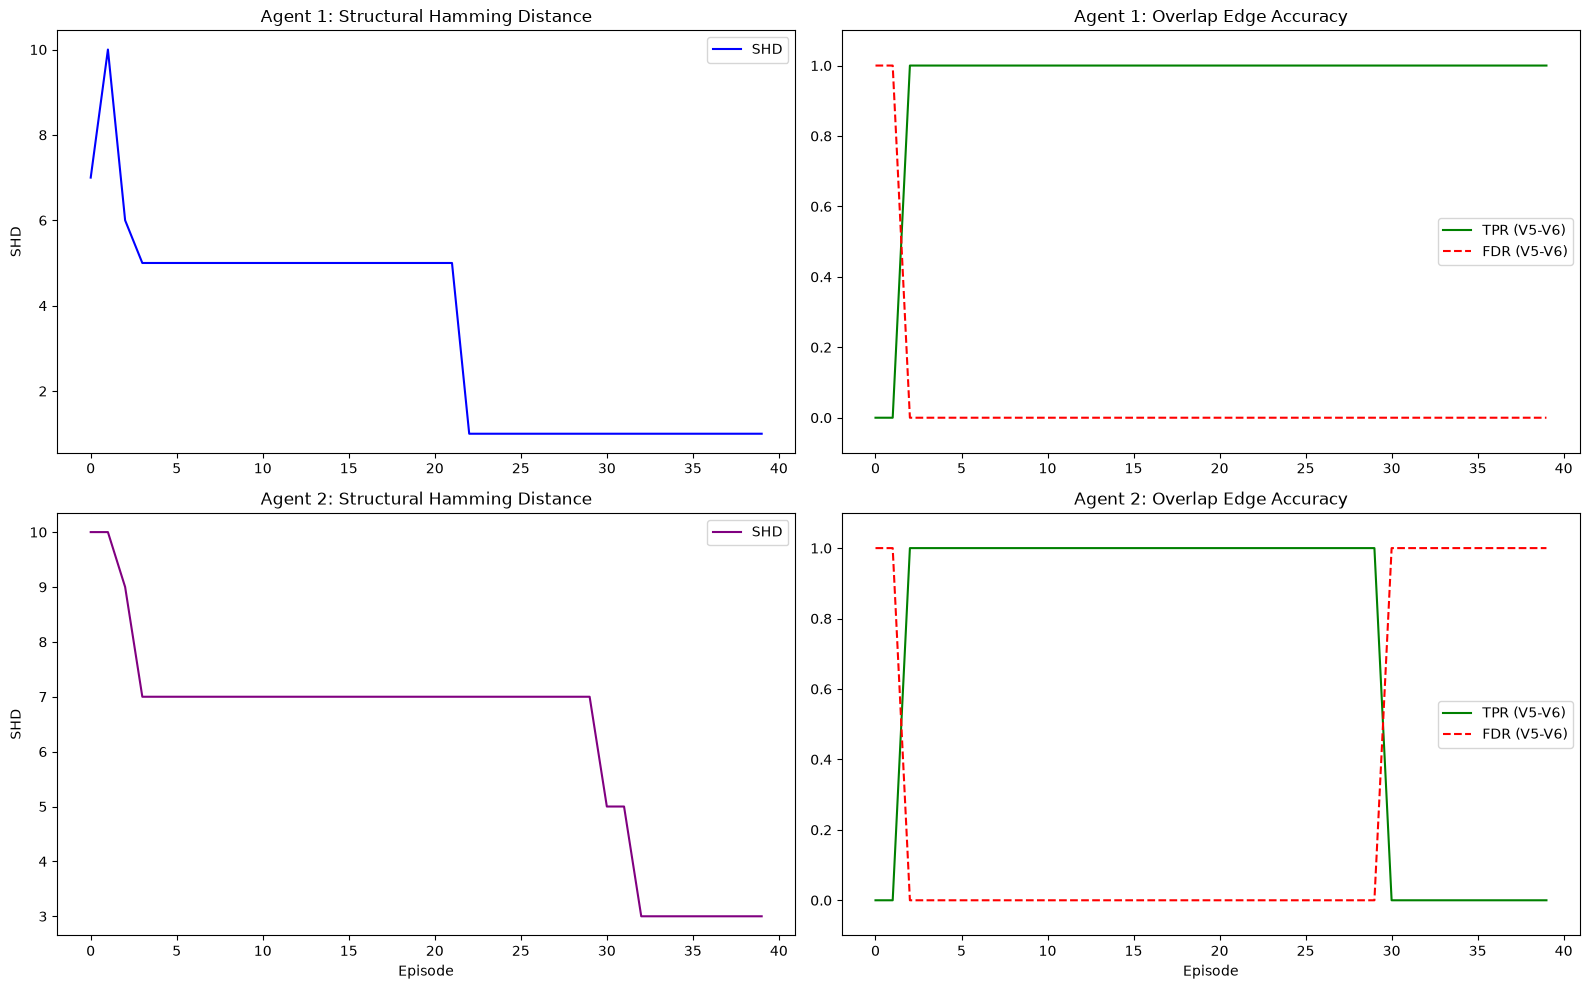

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Agent 1 Metrics
axs[0,0].plot(a1_metrics['shd'], color='blue', label='SHD')
axs[0,0].set_title("Agent 1: Structural Hamming Distance")
axs[0,0].set_ylabel("SHD")
axs[0,0].legend()

axs[0,1].plot(a1_metrics['tpr'], color='green', label='TPR (V5-V6)')
axs[0,1].plot(a1_metrics['fdr'], color='red', linestyle='--', label='FDR (V5-V6)')
axs[0,1].set_title("Agent 1: Overlap Edge Accuracy")
axs[0,1].set_ylim([-0.1, 1.1])
axs[0,1].legend()

# Agent 2 Metrics
axs[1,0].plot(a2_metrics['shd'], color='purple', label='SHD')
axs[1,0].set_title("Agent 2: Structural Hamming Distance")
axs[1,0].set_ylabel("SHD")
axs[1,0].set_xlabel("Episode")
axs[1,0].legend()

axs[1,1].plot(a2_metrics['tpr'], color='green', label='TPR (V5-V6)')
axs[1,1].plot(a2_metrics['fdr'], color='red', linestyle='--', label='FDR (V5-V6)')
axs[1,1].set_title("Agent 2: Overlap Edge Accuracy")
axs[1,1].set_ylim([-0.1, 1.1])
axs[1,1].set_xlabel("Episode")
axs[1,1].legend()

plt.tight_layout()
plt.show()


## Final Sub-Graph Comparisons
Below are the final directed acyclic graphs discovered by each agent compared to the true subgraphs extracted from the global model.


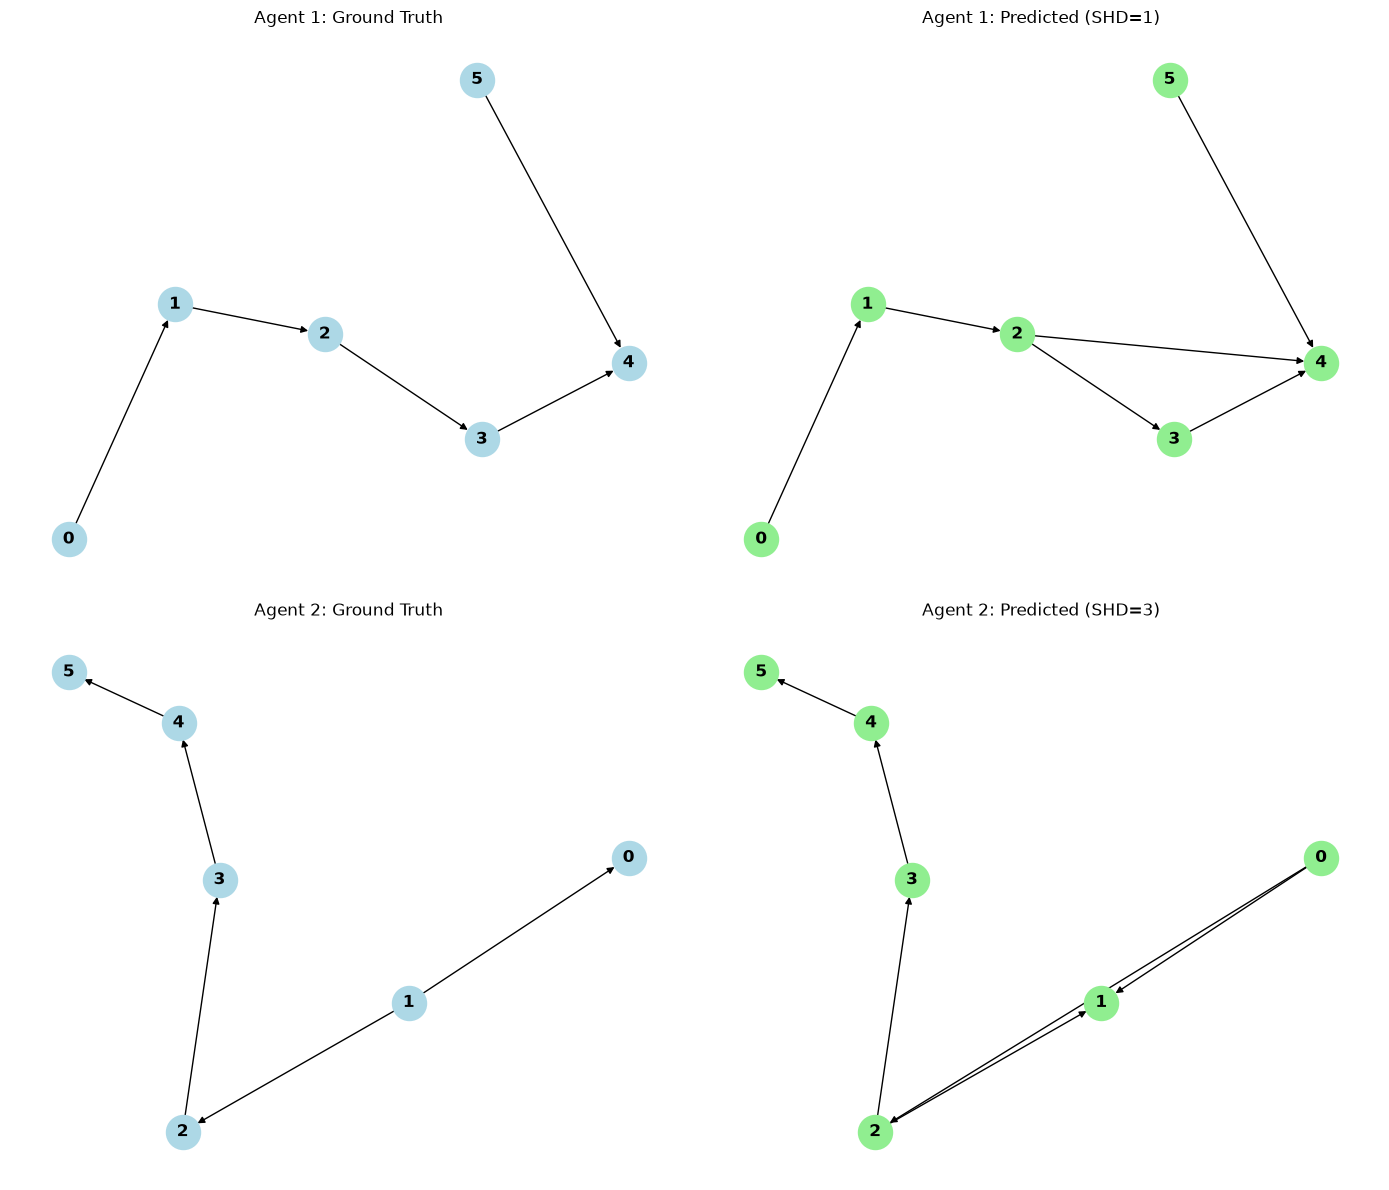

In [7]:
def draw_comparisons(true_dag, pred_dag, title_prefix, ax_true, ax_pred):
    G_true = nx.DiGraph(true_dag)
    G_pred = nx.DiGraph(pred_dag)
    pos = nx.spring_layout(G_true, seed=42)
    
    nx.draw(G_true, pos, ax=ax_true, with_labels=True, node_color='lightblue', node_size=600, font_weight='bold')
    ax_true.set_title(f"{title_prefix}: Ground Truth")
    
    nx.draw(G_pred, pos, ax=ax_pred, with_labels=True, node_color='lightgreen', node_size=600, font_weight='bold')
    final_shd = compute_shd(pred_dag, true_dag)
    ax_pred.set_title(f"{title_prefix}: Predicted (SHD={final_shd})")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

draw_comparisons(agent1_true_dag, a1_dag, "Agent 1", axes[0,0], axes[0,1])
draw_comparisons(agent2_true_dag, a2_dag, "Agent 2", axes[1,0], axes[1,1])

plt.tight_layout()
plt.show()
